# Stage 1C: Chart Detection (YOLO)

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 3.0.0 | 2026-01-27 | That Le | Simplified: YOLO detection only |

---

## Purpose

**Input:** Raw images from `data/academic_dataset/images/`

**Output:** Detected charts copied to `data/academic_dataset/detected_charts/`

**Next Step:** Manual review → 01d (classify + QA generation)

### Pipeline

```
01a_data_collection
        |
01b_image_extraction
        |
[01c_chart_detection]  <-- This notebook (YOLO only)
        |
        v
detected_charts/  --> Manual Review --> verified_charts/
        |
01d_classification_qa  (ResNet classify + QA)
```

In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# YOLO Detection Settings
YOLO_CONFIDENCE = 0.5     # Min confidence to detect a chart
EXECUTE_DETECTION = True  # Set False for dry run
MAX_IMAGES = None         # None = all images, or set a number for testing

print(f"Mode: {'ACTIVE' if EXECUTE_DETECTION else 'DRY RUN'}")
print(f"YOLO confidence threshold: {YOLO_CONFIDENCE}")

Mode: ACTIVE
YOLO confidence threshold: 0.5


In [2]:
# ============================================================================
# SETUP
# ============================================================================
import sys
from pathlib import Path
from datetime import datetime
import json
import shutil

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Directories
IMAGES_DIR = PROJECT_ROOT / "data" / "academic_dataset" / "images"
OUTPUT_DIR = PROJECT_ROOT / "data" / "academic_dataset" / "detected_charts"
PROGRESS_FILE = PROJECT_ROOT / "data" / "detection_progress.json"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:    {PROJECT_ROOT}")
print(f"Input images:    {IMAGES_DIR}")
print(f"Output charts:   {OUTPUT_DIR}")

Project root:    d:\elix\chart_analysis_ai_v3
Input images:    d:\elix\chart_analysis_ai_v3\data\academic_dataset\images
Output charts:   d:\elix\chart_analysis_ai_v3\data\academic_dataset\detected_charts


In [3]:
# ============================================================================
# CHECK CURRENT STATUS
# ============================================================================

all_images = list(IMAGES_DIR.glob("*.png")) + list(IMAGES_DIR.glob("*.jpg"))
detected_images = list(OUTPUT_DIR.glob("*.png")) + list(OUTPUT_DIR.glob("*.jpg"))

print("=" * 50)
print("DATASET STATUS")
print("=" * 50)
print(f"Total images:      {len(all_images):,}")
print(f"Already detected:  {len(detected_images):,}")
print(f"Pending:           {len(all_images) - len(detected_images):,}")
print("=" * 50)

DATASET STATUS
Total images:      198,887
Already detected:  0
Pending:           198,887


In [4]:
# ============================================================================
# LOAD YOLO MODEL
# ============================================================================
from ultralytics import YOLO

# Find YOLO model
possible_paths = [
    PROJECT_ROOT / "models" / "weights" / "yolo_chart_detector.pt",
    PROJECT_ROOT / "yolov8n.pt",
]

yolo_path = None
for p in possible_paths:
    if p.exists():
        yolo_path = p
        break

if yolo_path is None:
    raise FileNotFoundError("No YOLO model found!")

print(f"Loading YOLO: {yolo_path}")
model = YOLO(str(yolo_path))
print(f"Classes: {model.names}")
print("YOLO model loaded!")

Loading YOLO: d:\elix\chart_analysis_ai_v3\models\weights\yolo_chart_detector.pt
Classes: {0: 'chart'}
YOLO model loaded!


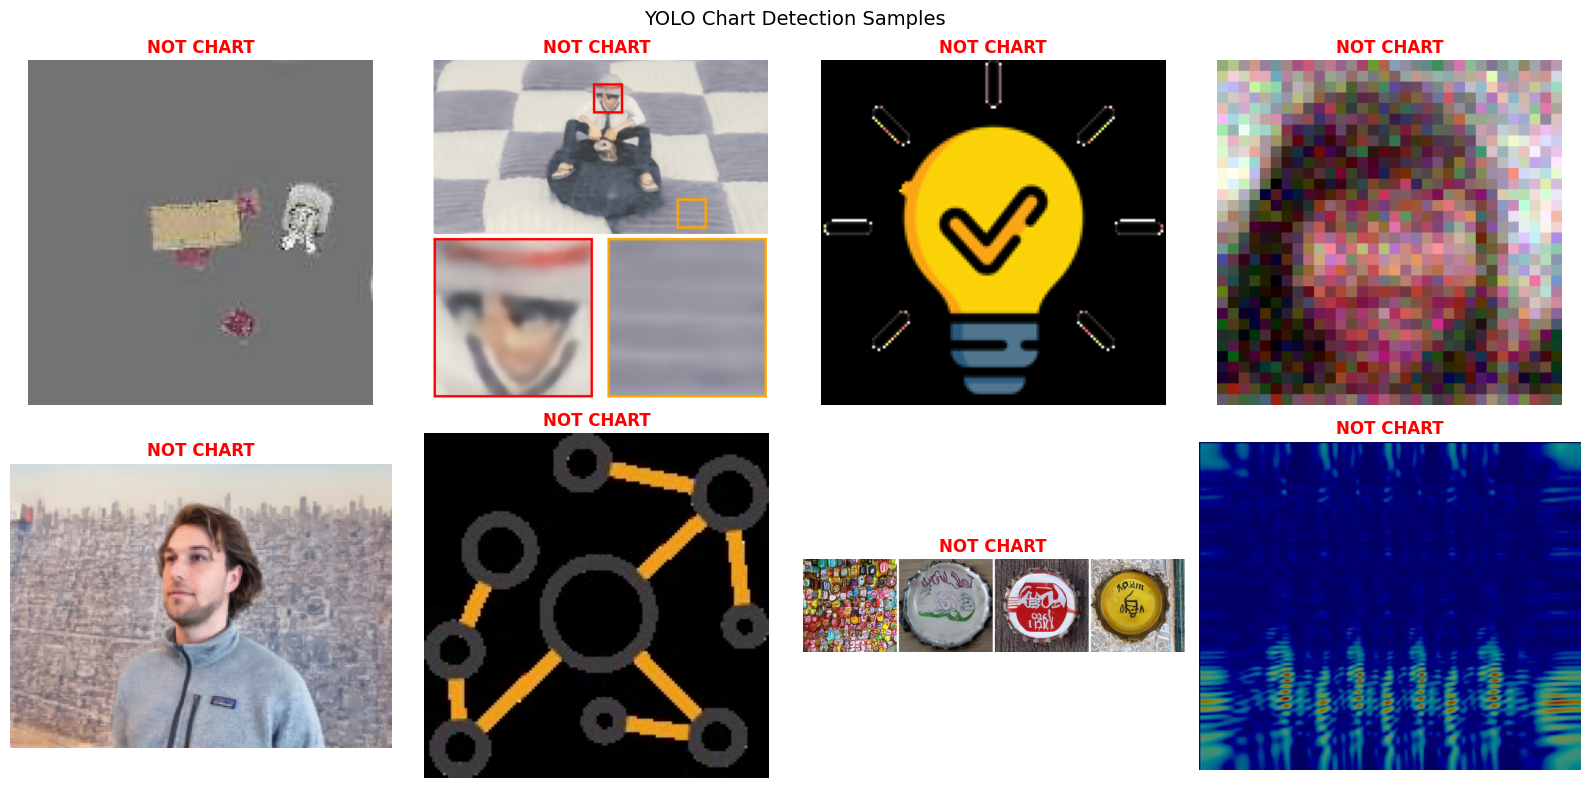

In [5]:
# ============================================================================
# TEST ON SAMPLES
# ============================================================================
import random
from PIL import Image
import matplotlib.pyplot as plt

# Random sample
samples = random.sample(all_images, min(8, len(all_images)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    # Detect
    results = model.predict(str(img_path), conf=YOLO_CONFIDENCE, verbose=False)
    detections = results[0].boxes
    is_chart = len(detections) > 0
    conf = detections.conf[0].item() if is_chart else 0
    
    # Display
    img = Image.open(img_path)
    ax.imshow(img)
    
    color = "green" if is_chart else "red"
    label = f"CHART ({conf:.2f})" if is_chart else "NOT CHART"
    ax.set_title(label, color=color, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("YOLO Chart Detection Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================================
# BATCH DETECTION
# ============================================================================
from tqdm.auto import tqdm
import time


def load_progress():
    """Load detection progress."""
    if PROGRESS_FILE.exists():
        with open(PROGRESS_FILE) as f:
            return json.load(f)
    return {"processed": [], "detected": 0, "skipped": 0}


def save_progress(progress):
    """Save detection progress."""
    with open(PROGRESS_FILE, "w") as f:
        json.dump(progress, f)


def detect_charts(
    image_dir: Path,
    output_dir: Path,
    confidence: float = 0.5,
    max_images: int = None,
    dry_run: bool = True,
):
    """
    Detect charts using YOLO and copy to output directory.
    
    Args:
        image_dir: Source directory
        output_dir: Destination for detected charts
        confidence: YOLO confidence threshold
        max_images: Limit number of images (None = all)
        dry_run: If True, don't copy files
    """
    progress = load_progress()
    processed_set = set(progress["processed"])
    
    # Get images
    images = list(image_dir.glob("*.png")) + list(image_dir.glob("*.jpg"))
    if max_images:
        images = images[:max_images]
    
    # Filter already processed
    pending = [p for p in images if p.name not in processed_set]
    
    print("=" * 60)
    print(f"YOLO CHART DETECTION | {'DRY RUN' if dry_run else 'ACTIVE'}")
    print(f"Confidence threshold: {confidence}")
    print(f"Total: {len(images):,} | Pending: {len(pending):,}")
    print("=" * 60)
    
    if dry_run:
        print("\n[DRY RUN] Set EXECUTE_DETECTION = True to run.")
        return progress
    
    start = time.time()
    detected_count = 0
    skipped_count = 0
    
    for img_path in tqdm(pending, desc="Detecting charts"):
        try:
            # YOLO inference
            results = model.predict(str(img_path), conf=confidence, verbose=False)
            is_chart = len(results[0].boxes) > 0
            
            if is_chart:
                # Copy chart to output
                shutil.copy2(img_path, output_dir / img_path.name)
                detected_count += 1
                progress["detected"] += 1
            else:
                skipped_count += 1
                progress["skipped"] += 1
            
            progress["processed"].append(img_path.name)
            
            # Checkpoint
            if len(progress["processed"]) % 1000 == 0:
                save_progress(progress)
                elapsed = time.time() - start
                print(f"  Checkpoint: {len(progress['processed']):,} | {elapsed:.0f}s")
                
        except KeyboardInterrupt:
            print("\n[INTERRUPTED] Saving...")
            save_progress(progress)
            break
        except Exception as e:
            print(f"Error: {img_path.name} - {e}")
    
    save_progress(progress)
    
    elapsed = time.time() - start
    rate = len(pending) / elapsed if elapsed > 0 else 0
    
    print("\n" + "=" * 60)
    print("DETECTION COMPLETE")
    print(f"  Charts detected: {detected_count:,}")
    print(f"  Non-charts:      {skipped_count:,}")
    print(f"  Time:            {elapsed:.1f}s ({rate:.1f} img/s)")
    print(f"  Output:          {output_dir}")
    print("=" * 60)
    
    return progress

d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# ============================================================================
# EXECUTE DETECTION
# ============================================================================

if EXECUTE_DETECTION:
    result = detect_charts(
        image_dir=IMAGES_DIR,
        output_dir=OUTPUT_DIR,
        confidence=YOLO_CONFIDENCE,
        max_images=MAX_IMAGES,
        dry_run=False,
    )
else:
    print("[SKIPPED] Set EXECUTE_DETECTION = True to run.")

YOLO CHART DETECTION | ACTIVE
Confidence threshold: 0.5
Total: 198,887 | Pending: 198,887


Detecting charts:   1%|          | 1004/198887 [00:20<1:19:08, 41.67it/s]

  Checkpoint: 1,000 | 21s


Detecting charts:   1%|          | 2011/198887 [00:49<44:11, 74.24it/s]  

  Checkpoint: 2,000 | 50s


...

  Checkpoint: 197,000 | 6398s


Detecting charts: 100%|█████████▉| 198002/198887 [1:47:16<00:50, 17.70it/s]

  Checkpoint: 198,000 | 6436s


Detecting charts: 100%|██████████| 198887/198887 [1:47:51<00:00, 30.73it/s]



DETECTION COMPLETE
  Charts detected: 50,865
  Non-charts:      148,022
  Time:            6471.4s (30.7 img/s)
  Output:          d:\elix\chart_analysis_ai_v3\data\academic_dataset\detected_charts


In [ ]:
# ============================================================================
# FINAL STATISTICS
# ============================================================================

detected = list(OUTPUT_DIR.glob("*.png")) + list(OUTPUT_DIR.glob("*.jpg"))

print("=" * 50)
print("DETECTION SUMMARY")
print("=" * 50)
print(f"Total input images:  {len(all_images):,}")
print(f"Charts detected:     {len(detected):,}")
print(f"Detection rate:      {len(detected)/len(all_images)*100:.1f}%")
print("=" * 50)
print()
print("NEXT STEPS:")
print(f"1. Review detected charts in: {OUTPUT_DIR}")
print("2. Remove false positives manually")
print("3. Run 01d_classification_qa.ipynb")

DETECTION SUMMARY
Total input images:  198,887
Charts detected:     50,865
Detection rate:      25.6%

NEXT STEPS:
1. Review detected charts in: d:\elix\chart_analysis_ai_v3\data\academic_dataset\detected_charts
2. Remove false positives manually
3. Run 01d_classification_qa.ipynb


: 

---

## Next: Manual Review

After detection:

1. **Review** `detected_charts/` folder
2. **Delete** false positives (diagrams, tables, etc.)
3. **Run** `01d_classification_qa.ipynb` to:
   - Classify chart types (ResNet-18)
   - Generate QA pairs